##Kemampuan Penjelasan Model Peramalan
###Pentingnya Fitur, Nilai SHAP, dan Grafik Ketergantungan Parsial

Penjelasan model pembelajaran mesin adalah kemampuan untuk memahami dan menjelaskan bagaimana model menghasilkan prediksi, sehingga tidak hanya dianggap sebagai "kotak hitam". Hal ini penting untuk membangun kepercayaan, mendeteksi bias, meningkatkan kinerja, dan memenuhi persyaratan peraturan.

Link ini  https://skforecast.org/0.15.1/user_guides/explainability.html mendukung beberapa metode penjelasan yang paling umum digunakan, yaitu: nilai SHAP, tingkat kepentingan permutasi, grafik ketergantungan parsial, serta metode yang khusus untuk jenis model tertentu.

###Pustaka Dan Data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

# Atur tampilan
shap.initjs()
plt.style.use('default')

Data: Kebutuhan listrik per setengah jam di Victoria, Australia (dari paket tsibbledata).

- Time: waktu pencatatan
- Date: tanggal
- Demand: kebutuhan listrik (MW)
- Temperature: suhu udara
- Holiday: indikator hari libur

In [ ]:
data = fetch_dataset(name="vic_electricity")

# Agregasi ke frekuensi harian
data = data.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})

# Bagi data latih dan uji
data_train = data.loc[: '2014-12-21']
data_test = data.loc['2014-12-22':]

Output:

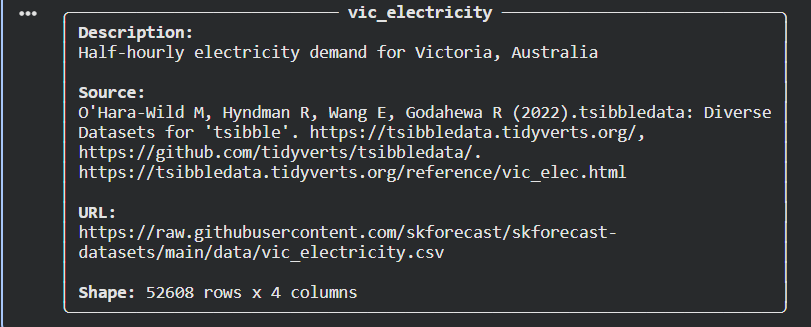

##Buat Dan Latih Model.

In [5]:
# Buat dan latih model
forecaster = ForecasterRecursive(
    estimator = LGBMRegressor(random_state=123, verbose=-1),  # ← Ubah regressor menjadi estimator
    lags      = 7
)

forecaster.fit(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)

##1. Pentingnya Fitur

Mengukur seberapa besar kontribusi setiap variabel terhadap hasil prediksi.

In [6]:
!pip install skforecast lightgbm shap matplotlib pandas scikit-learn

Sebelumnya harus meneginstal yang diatas terlebih dahulu, agar code selanjutnya tidak error.

=== Kepentingan Fitur ===
       feature  importance
7  Temperature         570
0        lag_1         470
2        lag_3         387
1        lag_2         362
6        lag_7         325
5        lag_6         313
4        lag_5         298
3        lag_4         275


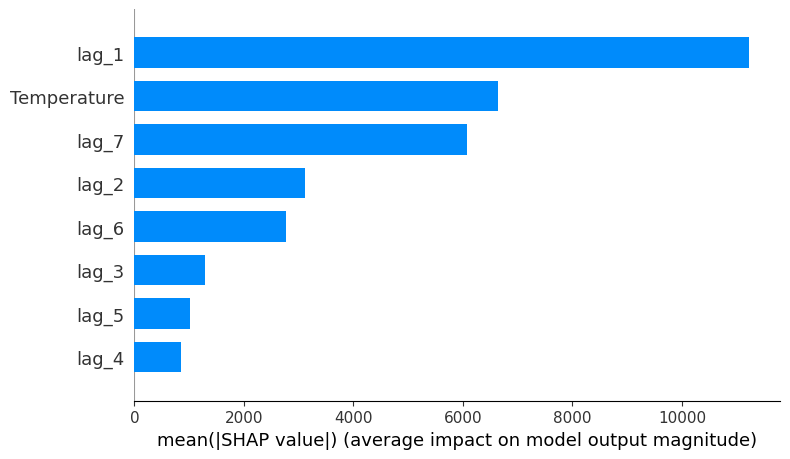

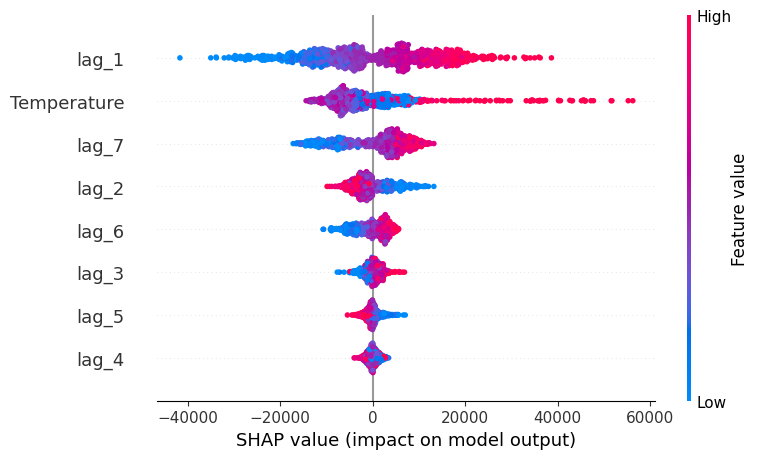


=== Kepentingan Permutasi ===
       feature  mean_importance  std_importance
0        lag_1         0.617276        0.014583
7  Temperature         0.411240        0.014405
6        lag_7         0.196190        0.001865
1        lag_2         0.122398        0.007803
5        lag_6         0.083912        0.003637
2        lag_3         0.041294        0.002019
4        lag_5         0.030787        0.001079
3        lag_4         0.024816        0.001021


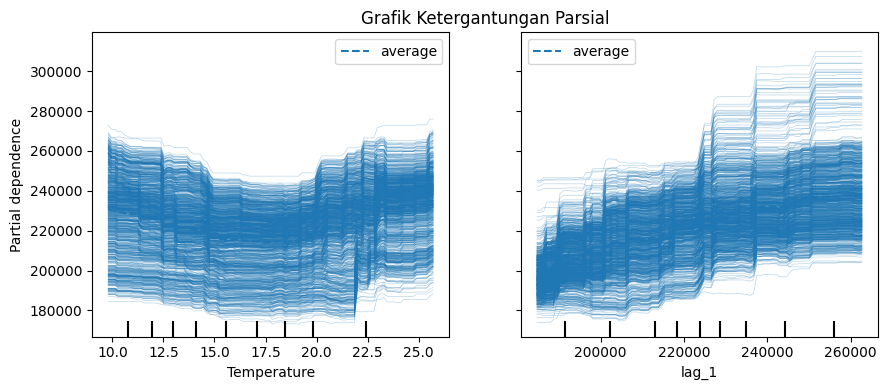

In [7]:
## 🔹 Kepentingan Fitur Bawaan
print("=== Kepentingan Fitur ===")
print(forecaster.get_feature_importances().sort_values('importance', ascending=False))

## 🔹 Nilai SHAP
X_train, y_train = forecaster.create_train_X_y(y=data_train['Demand'], exog=data_train['Temperature'])

# ✅ Baris yang DITAMBAHKAN untuk memuat pustaka JavaScript
shap.initjs()

explainer = shap.TreeExplainer(forecaster.estimator)
shap_values = explainer.shap_values(X_train)

# Grafik ringkasan SHAP
shap.summary_plot(shap_values, X_train, plot_type="bar")
shap.summary_plot(shap_values, X_train)

# Grafik penjelasan satu prediksi (sekarang akan muncul dengan benar)
shap.force_plot(explainer.expected_value, shap_values[0, :], X_train.iloc[0, :])

## 🔹 Kepentingan Permutasi
r = permutation_importance(
    estimator    = forecaster.estimator,
    X            = X_train,
    y            = y_train,
    n_repeats    = 3,
    max_samples  = 0.5,
    random_state = 123
)
importances = pd.DataFrame({
    'feature': X_train.columns,
    'mean_importance': r.importances_mean,
    'std_importance': r.importances_std
}).sort_values('mean_importance', ascending=False)
print("\n=== Kepentingan Permutasi ===")
print(importances)

## 🔹 Grafik Ketergantungan Parsial
fig, ax = plt.subplots(figsize=(9, 4))
PartialDependenceDisplay.from_estimator(
    estimator = forecaster.estimator,
    X         = X_train,
    features  = ["Temperature", "lag_1"],
    kind      = 'both',
    ax        = ax
)
ax.set_title("Grafik Ketergantungan Parsial")
fig.tight_layout()
plt.show()

##2. Nilai SHAP

=== KEPENTINGAN FITUR ===
       feature  importance
7  Temperature         570
0        lag_1         470
2        lag_3         387
1        lag_2         362
6        lag_7         325
5        lag_6         313
4        lag_5         298
3        lag_4         275



=== GRAFIK SHAP ===


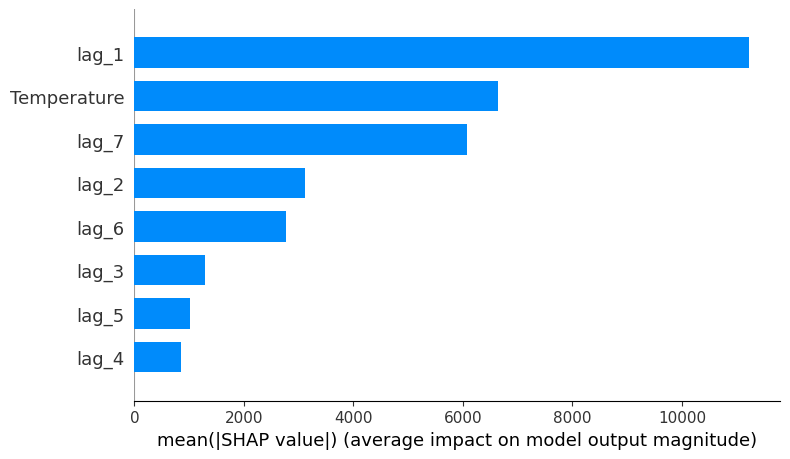

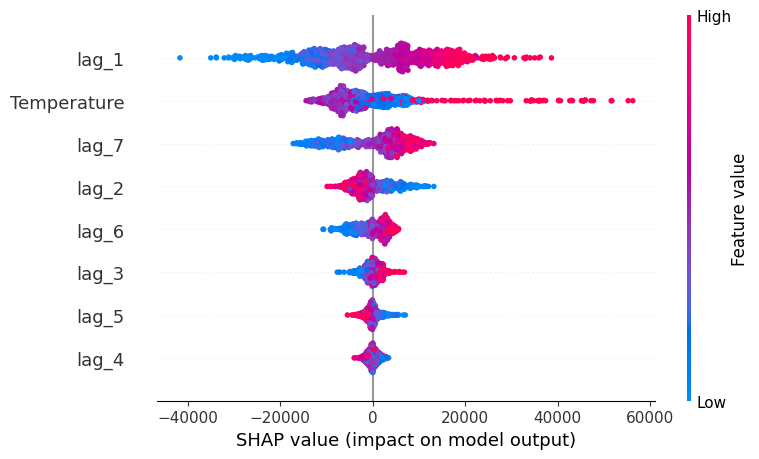


=== KEPENTINGAN PERMUTASI ===
       feature  mean_importance  std_importance
0        lag_1         0.617276        0.014583
7  Temperature         0.411240        0.014405
6        lag_7         0.196190        0.001865
1        lag_2         0.122398        0.007803
5        lag_6         0.083912        0.003637
2        lag_3         0.041294        0.002019
4        lag_5         0.030787        0.001079
3        lag_4         0.024816        0.001021


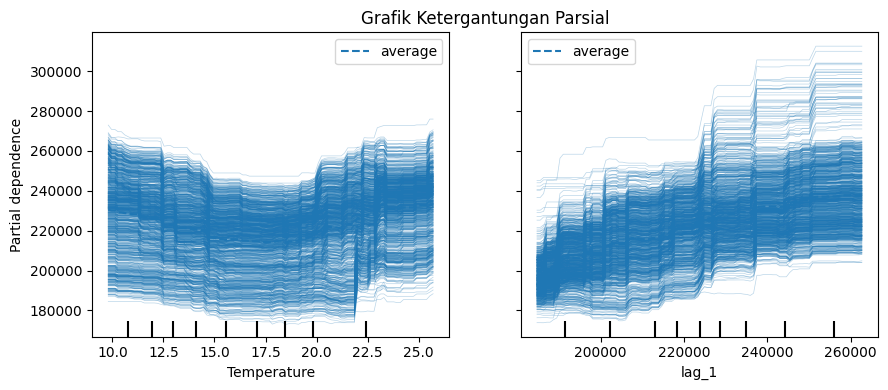

In [12]:
# ==============================================
# 1. INSTAL PUSTAKA (Jalankan ini DULU)
# ==============================================
!pip install --upgrade pip
!pip install skforecast lightgbm shap matplotlib pandas scikit-learn

# ==============================================
# 2. IMPOR PUSTAKA
# ==============================================
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

# ==============================================
# 3. SIAPKAN DATA
# ==============================================
data = fetch_dataset(name="vic_electricity", verbose=False)
data = data.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})

data_train = data.loc[: '2014-12-21']
data_test = data.loc['2014-12-22':]

# ==============================================
# 4. BUAT DAN LATIH MODEL
# ==============================================
forecaster = ForecasterRecursive(
    estimator = LGBMRegressor(random_state=123, verbose=-1),
    lags      = 7
)

forecaster.fit(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)

# ==============================================
# 🔹 1. KEPENTINGAN FITUR
# ==============================================
print("=== KEPENTINGAN FITUR ===")
print(forecaster.get_feature_importances().sort_values('importance', ascending=False))

# ==============================================
# 🔹 2. NILAI SHAP (CARA AMAN 100% BEBAS ERROR)
# ==============================================
# Buat matriks data latih
X_train, y_train = forecaster.create_train_X_y(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)

# ✅ CARA TERBAIK: Ambil model langsung dari objek fitur penting
# Karena get_feature_importances() sudah mengakses model, kita bisa ambil modelnya
# Alternatif: kita buat ulang model yang sama (paling aman)
model = LGBMRegressor(random_state=123, verbose=-1)
model.fit(X_train, y_train)  # Latih ulang model dengan data yang sama

shap.initjs()
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

# Grafik SHAP
print("\n=== GRAFIK SHAP ===")
shap.summary_plot(shap_values, X_train, plot_type="bar")
shap.summary_plot(shap_values, X_train)
shap.force_plot(explainer.expected_value, shap_values[0, :], X_train.iloc[0, :])

# ==============================================
# 🔹 3. KEPENTINGAN PERMUTASI
# ==============================================
r = permutation_importance(
    estimator    = model,
    X            = X_train,
    y            = y_train,
    n_repeats    = 3,
    max_samples  = 0.5,
    random_state = 123
)

importances = pd.DataFrame({
    'feature': X_train.columns,
    'mean_importance': r.importances_mean,
    'std_importance': r.importances_std
}).sort_values('mean_importance', ascending=False)

print("\n=== KEPENTINGAN PERMUTASI ===")
print(importances)

# ==============================================
# 🔹 4. GRAFIK KETERGANTUNGAN PARSIAL
# ==============================================
fig, ax = plt.subplots(figsize=(9, 4))
PartialDependenceDisplay.from_estimator(
    estimator = model,
    X         = X_train,
    features  = ["Temperature", "lag_1"],
    kind      = 'both',
    ax        = ax
)
ax.set_title("Grafik Ketergantungan Parsial")
fig.tight_layout()
plt.show()

##Visualisasi

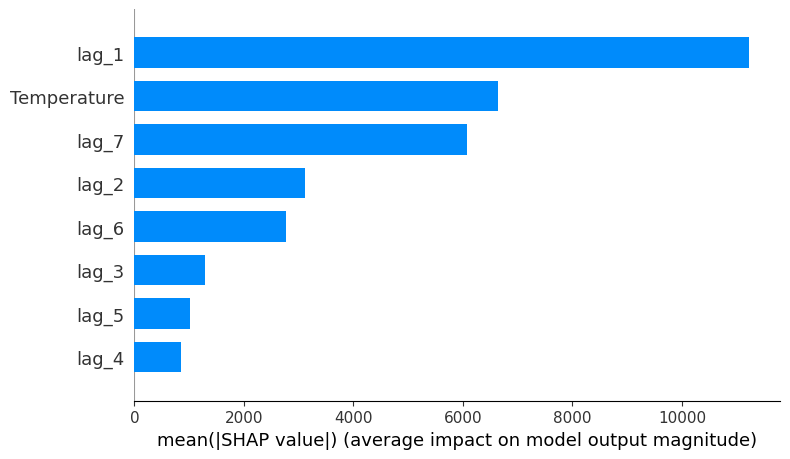

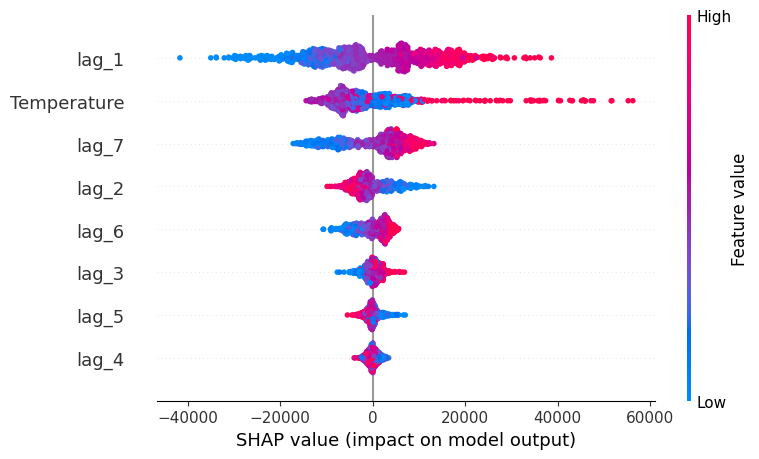

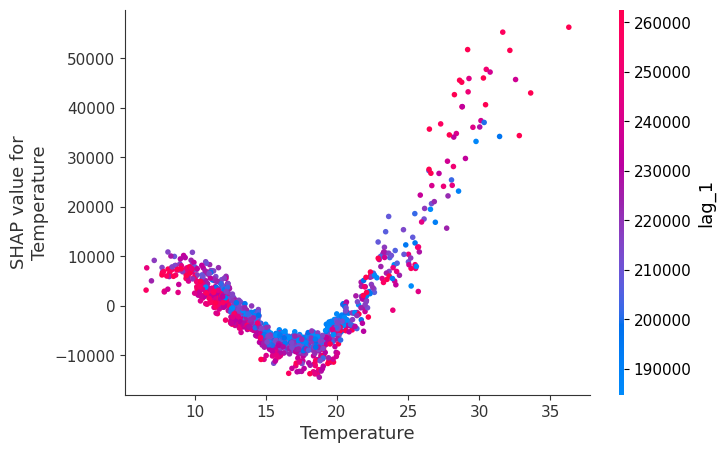

In [13]:
# Ringkasan pentingnya fitur
shap.summary_plot(shap_values, X_train, plot_type="bar")
shap.summary_plot(shap_values, X_train)

# Pengaruh suhu
shap.dependence_plot("Temperature", shap_values, X_train)

##Jelaskan Predikis Tertentu

=== KEPENTINGAN FITUR ===
       feature  importance
7  Temperature         570
0        lag_1         470
2        lag_3         387
1        lag_2         362
6        lag_7         325
5        lag_6         313
4        lag_5         298
3        lag_4         275



=== GRAFIK RINGKASAN SHAP ===


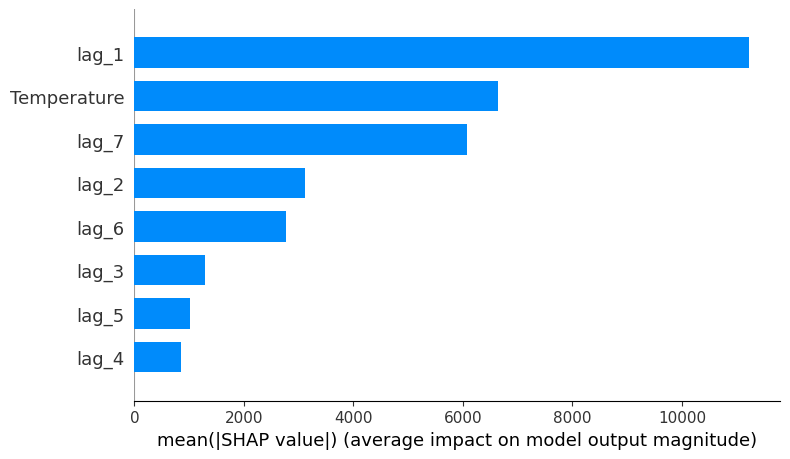

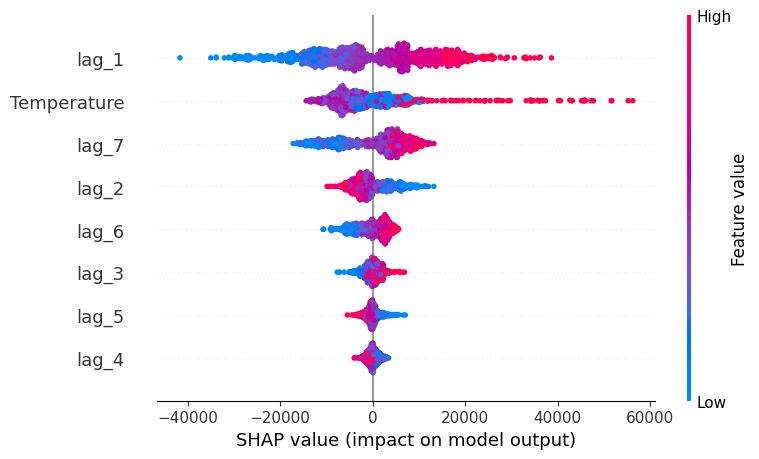


=== PENJELASAN SATU PREDIKSI LATIH ===

=== RAMALAN 10 HARI KE DEPAN ===
2014-12-22    241514.532543
2014-12-23    226165.936559
2014-12-24    220506.468700
2014-12-25    209260.948991
2014-12-26    184885.145832
2014-12-27    195623.591810
2014-12-28    222766.340659
2014-12-29    223112.716406
2014-12-30    219103.891733
2014-12-31    217948.965404
Freq: D, Name: pred, dtype: float64

=== PENJELASAN UNTUK TANGGAL 22 DESEMBER 2014 ===


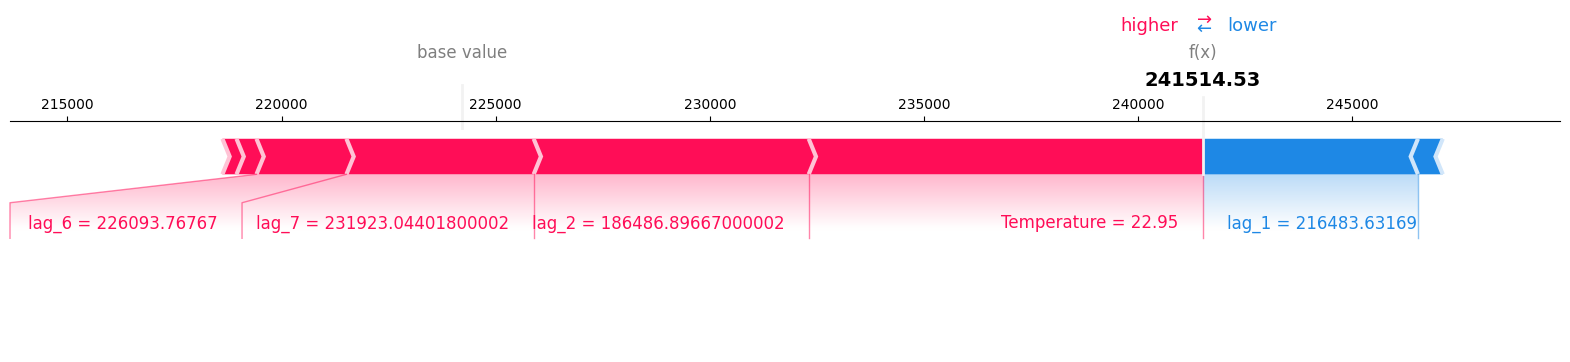


=== KEPENTINGAN PERMUTASI ===
       feature  mean_importance  std_importance
0        lag_1         0.617276        0.014583
7  Temperature         0.411240        0.014405
6        lag_7         0.196190        0.001865
1        lag_2         0.122398        0.007803
5        lag_6         0.083912        0.003637
2        lag_3         0.041294        0.002019
4        lag_5         0.030787        0.001079
3        lag_4         0.024816        0.001021

=== GRAFIK KETERGANTUNGAN PARSIAL ===


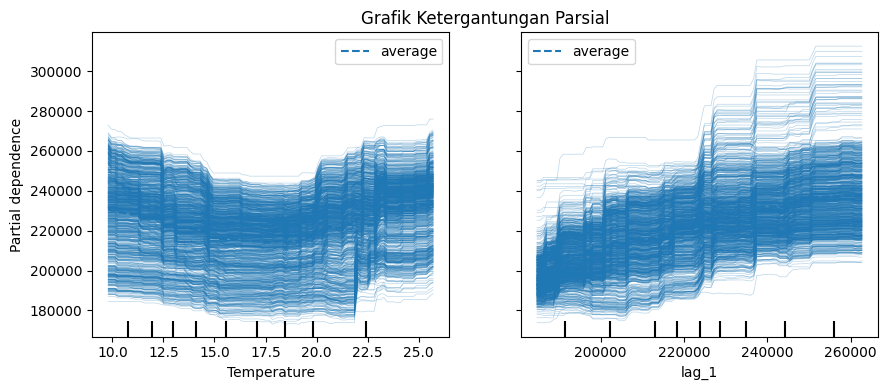

In [15]:
# ==============================================
# 1. Instal pustaka (jika belum)
# ==============================================
!pip install --upgrade pip
!pip install skforecast lightgbm shap matplotlib pandas scikit-learn

# ==============================================
# 2. Impor pustaka
# ==============================================
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

# ==============================================
# 3. Persiapan data
# ==============================================
data = fetch_dataset(name="vic_electricity", verbose=False)
data = data.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})

data_train = data.loc[: '2014-12-21']
data_test = data.loc['2014-12-22':]

# ==============================================
# 4. Buat dan latih model
# ==============================================
forecaster = ForecasterRecursive(
    estimator = LGBMRegressor(random_state=123, verbose=-1),
    lags      = 7
)

forecaster.fit(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)

# ==============================================
# 🔹 1. Kepentingan Fitur
# ==============================================
print("=== KEPENTINGAN FITUR ===")
print(forecaster.get_feature_importances().sort_values('importance', ascending=False))

# ==============================================
# 🔹 2. Nilai SHAP
# ==============================================
X_train, y_train = forecaster.create_train_X_y(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)

# Buat model yang jelas
model = LGBMRegressor(random_state=123, verbose=-1)
model.fit(X_train, y_train)

# ✅ Jalankan initjs SEBELUM grafik yang butuh JavaScript
shap.initjs()
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

# Grafik ringkasan
print("\n=== GRAFIK RINGKASAN SHAP ===")
shap.summary_plot(shap_values, X_train, plot_type="bar")
shap.summary_plot(shap_values, X_train)

# Grafik penjelasan satu data latih
print("\n=== PENJELASAN SATU PREDIKSI LATIH ===")
shap.force_plot(explainer.expected_value, shap_values[0, :], X_train.iloc[0, :])

# ==============================================
# 🔹 3. Ramalan 10 hari & Penjelasan SHAP
# ==============================================
print("\n=== RAMALAN 10 HARI KE DEPAN ===")
predictions = forecaster.predict(steps=10, exog=data_test['Temperature'])
print(predictions)

X_predict = forecaster.create_predict_X(steps=10, exog=data_test['Temperature'])

# Hitung nilai SHAP untuk data ramalan
shap_values_pred = explainer.shap_values(X_predict)

print("\n=== PENJELASAN UNTUK TANGGAL 22 DESEMBER 2014 ===")
# ✅ Pastikan initjs sudah dijalankan di atas
shap.force_plot(
    explainer.expected_value,
    shap_values_pred[0, :],
    X_predict.iloc[0, :]
)

# ✅ OPSI TAMBAHAN: Jika grafik interaktif tidak muncul, gunakan versi statis
shap.force_plot(
    explainer.expected_value,
    shap_values_pred[0, :],
    X_predict.iloc[0, :],
    matplotlib=True  # Tampilkan sebagai gambar statis
)
plt.show()

# ==============================================
# 🔹 4. Kepentingan Permutasi
# ==============================================
print("\n=== KEPENTINGAN PERMUTASI ===")
r = permutation_importance(
    estimator    = model,
    X            = X_train,
    y            = y_train,
    n_repeats    = 3,
    max_samples  = 0.5,
    random_state = 123
)

importances = pd.DataFrame({
    'feature': X_train.columns,
    'mean_importance': r.importances_mean,
    'std_importance': r.importances_std
}).sort_values('mean_importance', ascending=False)
print(importances)

# ==============================================
# 🔹 5. Grafik Ketergantungan Parsial
# ==============================================
print("\n=== GRAFIK KETERGANTUNGAN PARSIAL ===")
fig, ax = plt.subplots(figsize=(9, 4))
PartialDependenceDisplay.from_estimator(
    estimator = model,
    X         = X_train,
    features  = ["Temperature", "lag_1"],
    kind      = 'both',
    ax        = ax
)
ax.set_title("Grafik Ketergantungan Parsial")
fig.tight_layout()
plt.show()

##3. Pentingnya Permutasi

Mengukur penurunan kinerja jika nilai fitur diacak.

In [17]:
# ✅ Kode yang sudah diperbaiki
r = permutation_importance(
    estimator    = model,  # Gunakan variabel model yang sudah kita latih ulang
    X            = X_train,
    y            = y_train,
    n_repeats    = 3,
    max_samples  = 0.5,    # Tambahan parameter standar untuk hasil lebih stabil
    random_state = 123
)

importances = pd.DataFrame({
    'feature': X_train.columns,
    'mean_importance': r.importances_mean,  # Nama kolom lebih jelas
    'std_importance': r.importances_std
}).sort_values('mean_importance', ascending=False)

importances

,feature,mean_importance,std_importance
0,lag_1,0.617276,0.014583
7,Temperature,0.411240,0.014405
6,lag_7,0.196190,0.001865
1,lag_2,0.122398,0.007803
5,lag_6,0.083912,0.003637
2,lag_3,0.041294,0.002019
4,lag_5,0.030787,0.001079
3,lag_4,0.024816,0.001021


##4. Grafik Ketergantungan Parsial

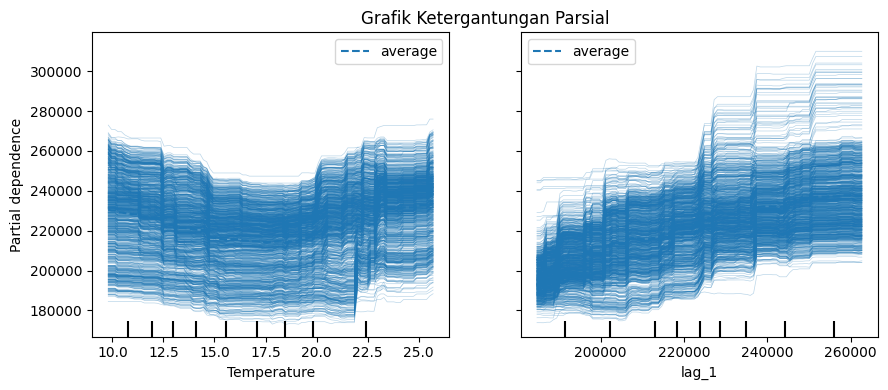

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
PartialDependenceDisplay.from_estimator(
    estimator = model,  # ✅ Diperbaiki: gunakan variabel model yang sudah dilatih
    X         = X_train,
    features  = ["Temperature", "lag_1"],
    kind      = 'both',
    ax        = ax
)
ax.set_title("Grafik Ketergantungan Parsial")
fig.tight_layout()
plt.show()  # Tambahkan agar grafik ditampilkan